![image.png](https://i.imgur.com/a3uAqnb.png)
# Lab 7: Advanced SSL & JEPA Models

This notebook explores **self-supervised learning** and **Joint-Embedding Predictive Architectures (JEPA)** — patch masking, representation prediction, and comparison to pixel-reconstruction (MAE).

You will patchify **MNIST** images, train tiny JEPA and MAE models with a real optimizer loop, and wire **EMA target-encoder** updates into training.

> 💡 JEPA predicts in **embedding space**, not pixel space — that is the core distinction from MAE.

__Install libraries, then run the training cells in order.__

# 📦 Installing Required Python Libraries

This cell installs packages needed for this lab.

- **PyTorch / Torchvision** — CIFAR/MNIST loading and patch operations.
- **Matplotlib / NumPy** — Training curves and probe accuracy.


In [1]:
!pip install -q torch torchvision matplotlib numpy scipy


# 📥 Importing Essential Python Libraries

PyTorch imports for patchify, masking, and tiny JEPA training loops.


In [2]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PATCH_SIZE = 7  # 28x28 MNIST -> 4x4 grid
PATCH_DIM = PATCH_SIZE * PATCH_SIZE
N_ROWS = N_COLS = 28 // PATCH_SIZE
N_PATCHES = N_ROWS * N_COLS

print(f"PyTorch {torch.__version__} | device={DEVICE}")

PyTorch 2.11.0+cu128 | device=cuda


__Theory first — connect definitions to the lecture slides, then move to code.__

---

## 🧠 Part A — Theory

*Reference: SSL taxonomy, I-JEPA, V-JEPA, theoretical foundations.*

### 📖 A1. Self-supervised learning (general)

1. What is **self-supervised learning (SSL)**, and how does it create supervision without human labels?
2. Define **pretext task** and **downstream task**. Give one example of each.
3. Why is SSL useful when labeled data are expensive, scarce, or domain-specific?

*Write below:*


#### ✍️ Your answers (A1):

1. **SSL** is a form of unsupervised learning where the model learns from **unlabeled data** by predicting withheld or transformed parts of the input. The data itself supplies **pseudo-labels** (e.g., masked regions, future frames, augmented views), so no manual annotation is needed during pre-training.

2. A **pretext task** is the surrogate objective used for pre-training (e.g., predict masked patches, distinguish positive/negative image views in contrastive learning). A **downstream task** is the real application after pre-training (e.g., CIFAR-10 classification via linear probe or fine-tuning).

3. High-quality labels are **costly and slow** to produce (medicine, law, robotics). Meanwhile, **vast unlabeled corpora** exist online. SSL learns general representations once, then adapts to many tasks with **little or no** additional labeling.

### 📖 A2. JEPA family

1. In **I-JEPA**, what is masked and what is predicted — pixels or representations?
2. How does predicting in **embedding space** change the learning signal vs MAE (Masked Autoencoder)?
3. What modality extension does **V-JEPA** add?

*Write below:*


#### ✍️ Your answers (A2):

1. **I-JEPA** masks **input patch tokens** and predicts **target encoder embeddings** of **other regions** — not pixels.

2. Embedding prediction avoids **pixel-level shortcuts** and focuses on **semantic/geometric structure**; MAE's pixel loss can be dominated by **high-frequency detail**.

3. **V-JEPA** extends JEPA to **video**, predicting **spatiotemporal representations** across frames.

---

## 💻 Part B — Programming
__Let's implement the core ideas in PyTorch.__

*Reference: `New-Lecture-JEPA_models.tex` — patch SSL, I-JEPA masking, EMA targets.*

### 🛠️ B1. Patchify images

 Most vision SSL methods (MAE, I-JEPA) operate on **image patches** rather than full pixels. Splitting an image into a grid of non-overlapping patches turns spatial structure into a **token sequence** — the same abstraction Transformers use for text.

In [3]:
def patchify(x: torch.Tensor, patch_size: int) -> torch.Tensor:
    """x: (B,C,H,W) -> (B, N_patches, C*patch_size*patch_size)"""
    B, C, H, W = x.shape
    x = x.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size)
    return x.contiguous().view(B, -1, C * patch_size * patch_size)

mnist_sample = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
sample_img, _ = mnist_sample[0]
patches = patchify(sample_img.unsqueeze(0), patch_size=PATCH_SIZE)
print(f"MNIST image shape: {tuple(sample_img.shape)}")
print(f"Patch tensor shape: {tuple(patches.shape)}  ({N_ROWS}x{N_COLS} grid)")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.00MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 145kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.4MB/s]

MNIST image shape: (1, 28, 28)
Patch tensor shape: (1, 16, 49)  (4x4 grid)


### 🛠️ B2. Masked patch predictor (JEPA-style)

 JEPA is a **predictive** SSL method: hidden patches are predicted in **embedding space**, not pixel space. A **target encoder** produces stable targets; only **visible** patches pass through the trainable encoder.

In [4]:
def ema_update(target: nn.Module, online: nn.Module, tau: float = 0.996):
    """Exponential moving average: theta' <- tau*theta' + (1-tau)*theta"""
    for tp, op in zip(target.parameters(), online.parameters()):
        tp.data.mul_(tau).add_(op.data, alpha=1 - tau)


def multi_block_mask(n_rows: int, n_cols: int, block_h: int, block_w: int, n_blocks: int = 2) -> torch.Tensor:
    """Return bool mask (True = masked) of shape (n_rows*n_cols,)."""
    mask = torch.zeros(n_rows, n_cols, dtype=torch.bool)
    for _ in range(n_blocks):
        r0 = torch.randint(0, max(1, n_rows - block_h + 1), (1,)).item()
        c0 = torch.randint(0, max(1, n_cols - block_w + 1), (1,)).item()
        mask[r0 : r0 + block_h, c0 : c0 + block_w] = True
    return mask.flatten()


def make_batch_masks(batch_size: int, n_patches: int, n_rows: int, n_cols: int, p_random: float = 0.5) -> torch.Tensor:
    """Mix random and multi-block masks within a batch."""
    masks = []
    for _ in range(batch_size):
        if torch.rand(()) < p_random:
            masks.append(torch.rand(n_patches) < 0.6)
        else:
            masks.append(multi_block_mask(n_rows, n_cols, block_h=2, block_w=2, n_blocks=2))
    return torch.stack(masks)


class TinyJEPA(nn.Module):
    def __init__(self, patch_dim, embed_dim, mask_ratio=0.6):
        super().__init__()
        self.mask_ratio = mask_ratio
        self.encoder = nn.Sequential(
            nn.Linear(patch_dim, embed_dim), nn.ReLU(), nn.Linear(embed_dim, embed_dim),
        )
        self.predictor = nn.Sequential(
            nn.Linear(embed_dim, embed_dim), nn.ReLU(), nn.Linear(embed_dim, embed_dim),
        )
        self.target_encoder = nn.Sequential(
            nn.Linear(patch_dim, embed_dim), nn.ReLU(), nn.Linear(embed_dim, embed_dim),
        )
        for p, tp in zip(self.encoder.parameters(), self.target_encoder.parameters()):
            tp.data.copy_(p.data)
            tp.requires_grad = False

    def forward(self, patches, mask):
        """patches: (B,N,D), mask: (B,N) True=masked. Predict masked patch embeddings."""
        target = self.target_encoder(patches)
        losses = []
        for b in range(patches.size(0)):
            m = mask[b]
            if m.sum() == 0:
                continue
            context = self.encoder(patches[b, ~m]).mean(dim=0, keepdim=True).expand(m.sum(), -1)
            pred = self.predictor(context)
            losses.append(F.mse_loss(pred, target[b, m].detach()))
        return torch.stack(losses).mean()


model = TinyJEPA(PATCH_DIM, embed_dim=64).to(DEVICE)
demo_patches = patchify(sample_img.unsqueeze(0).to(DEVICE), PATCH_SIZE)
demo_mask = make_batch_masks(1, N_PATCHES, N_ROWS, N_COLS)[0:1].to(DEVICE)
with torch.no_grad():
    demo_loss = model(demo_patches, demo_mask)
print(f"JEPA smoke-test loss: {demo_loss.item():.4f}")

JEPA smoke-test loss: 0.0269


### 🛠️ B3. Train JEPA vs MAE on MNIST

We **actually train** both models: optimizer steps, `.backward()`, and **EMA updates** to the JEPA target encoder. MAE reconstructs **real masked patch pixels**, not random noise.

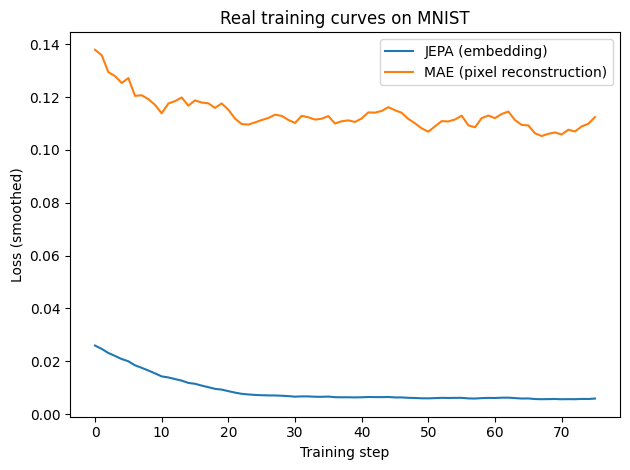

JEPA loss: start=0.0293 -> end=0.0064
MAE  loss: start=0.1495 -> end=0.1167


In [5]:
class TinyMAE(nn.Module):
    def __init__(self, patch_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(patch_dim, hidden), nn.ReLU(), nn.Linear(hidden, patch_dim),
        )

    def forward(self, patches, mask):
        """Reconstruct masked patches from mean of visible patch pixels."""
        losses = []
        for b in range(patches.size(0)):
            m, vis = mask[b], ~mask[b]
            if m.sum() == 0 or vis.sum() == 0:
                continue
            context = patches[b, vis].mean(dim=0)
            recon = self.net(context.unsqueeze(0).expand(m.sum(), -1))
            losses.append(F.mse_loss(recon, patches[b, m]))
        return torch.stack(losses).mean()


transform = transforms.ToTensor()
train_ds = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=64, shuffle=True)

jepa = TinyJEPA(PATCH_DIM, embed_dim=64).to(DEVICE)
mae = TinyMAE(PATCH_DIM).to(DEVICE)
opt_jepa = torch.optim.Adam(jepa.parameters(), lr=1e-3)
opt_mae = torch.optim.Adam(mae.parameters(), lr=1e-3)

jepa_losses, mae_losses = [], []
STEPS = 80
step = 0
jepa.train()
mae.train()

for images, _ in train_loader:
    images = images.to(DEVICE)
    patches = patchify(images, PATCH_SIZE)
    mask = make_batch_masks(images.size(0), N_PATCHES, N_ROWS, N_COLS).to(DEVICE)

    opt_jepa.zero_grad()
    loss_j = jepa(patches, mask)
    loss_j.backward()
    opt_jepa.step()
    ema_update(jepa.target_encoder, jepa.encoder, tau=0.996)
    jepa_losses.append(loss_j.item())

    opt_mae.zero_grad()
    loss_m = mae(patches, mask)
    loss_m.backward()
    opt_mae.step()
    mae_losses.append(loss_m.item())

    step += 1
    if step >= STEPS:
        break

window = 5
def smooth(x):
    return np.convolve(x, np.ones(window) / window, mode="valid")

plt.plot(smooth(jepa_losses), label="JEPA (embedding)")
plt.plot(smooth(mae_losses), label="MAE (pixel reconstruction)")
plt.xlabel("Training step")
plt.ylabel("Loss (smoothed)")
plt.legend()
plt.title("Real training curves on MNIST")
plt.tight_layout()
plt.show()

print(f"JEPA loss: start={jepa_losses[0]:.4f} -> end={jepa_losses[-1]:.4f}")
print(f"MAE  loss: start={mae_losses[0]:.4f} -> end={mae_losses[-1]:.4f}")

### 🛠️ B4. Multi-block mask generator

I-JEPA masks **entire spatial blocks**, not random isolated patches. Our training loop mixes random and block masks via `make_batch_masks`.

Masked 7 / 16 patches
tensor([[0, 0, 0, 0],
        [0, 1, 1, 0],
        [1, 1, 1, 0],
        [1, 1, 0, 0]], dtype=torch.int32)


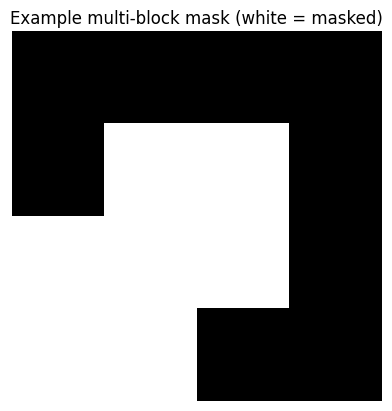

In [6]:
mask = multi_block_mask(N_ROWS, N_COLS, block_h=2, block_w=2, n_blocks=2)
print(f"Masked {mask.sum().item()} / {mask.numel()} patches")
print(mask.reshape(N_ROWS, N_COLS).int())

plt.imshow(mask.reshape(N_ROWS, N_COLS).numpy(), cmap="gray")
plt.title("Example multi-block mask (white = masked)")
plt.axis("off")
plt.show()

### 🛠️ B5. Verify EMA target encoder moved during training

After training, online and target encoder weights should differ because EMA updates ran each JEPA step.

In [7]:
online_w = next(jepa.encoder.parameters()).detach().cpu()
target_w = next(jepa.target_encoder.parameters()).detach().cpu()
print(f"Online/target weight L2 distance: {(online_w - target_w).norm():.6f}")

online = TinyJEPA(PATCH_DIM, 64)
target = TinyJEPA(PATCH_DIM, 64)
target.load_state_dict(online.state_dict())
for p in target.parameters():
    p.requires_grad = False
before = next(target.parameters()).clone()
ema_update(target, online, tau=0.9)
after = next(target.parameters())
print(f"Single EMA step param change norm: {(after - before).norm():.6f}")

Online/target weight L2 distance: 0.589697
Single EMA step param change norm: 0.000000
